In [1]:
from astropy.io import fits
import os
import matplotlib.pyplot as plt
import matplotlib as mpl

# Plotting set up
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 120

inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]
viridis = mpl.colormaps["viridis"]

inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)

In [2]:
uncal_dir = "/Volumes/research-data/PRJ-PAT/max/data/JWST/DARKS/all_uncal"

files = []
for f in os.listdir(uncal_dir):
    if f.startswith("."):
        continue
    files.append(fits.open(os.path.join(uncal_dir, f)))

In [3]:
import jax.numpy as np

badpix = np.load("/Volumes/research-data/PRJ-PAT/max/data/amigo_cache/full_badpix.npy")

F430M


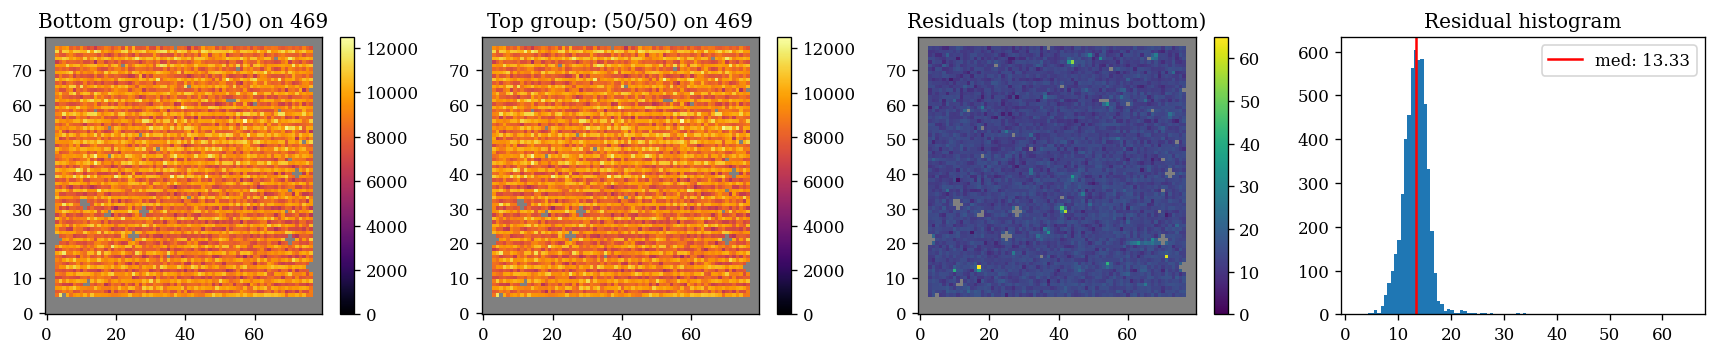

F430M


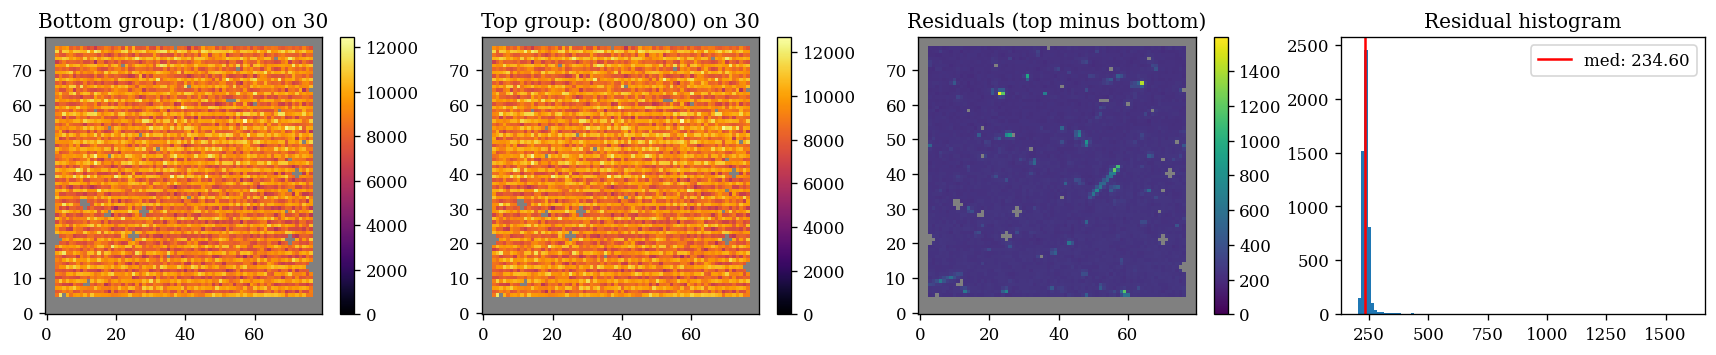

F430M


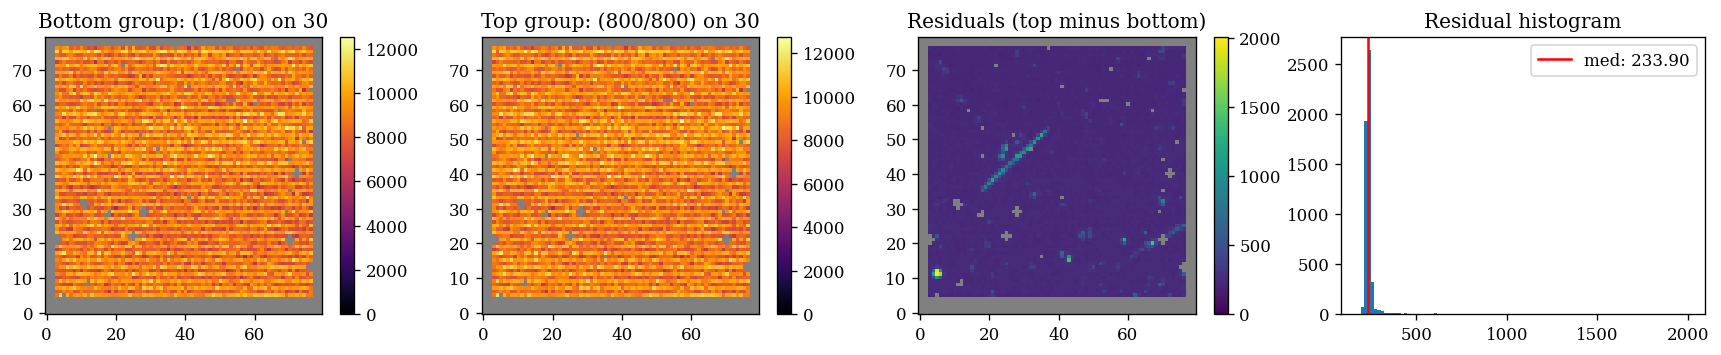

F430M


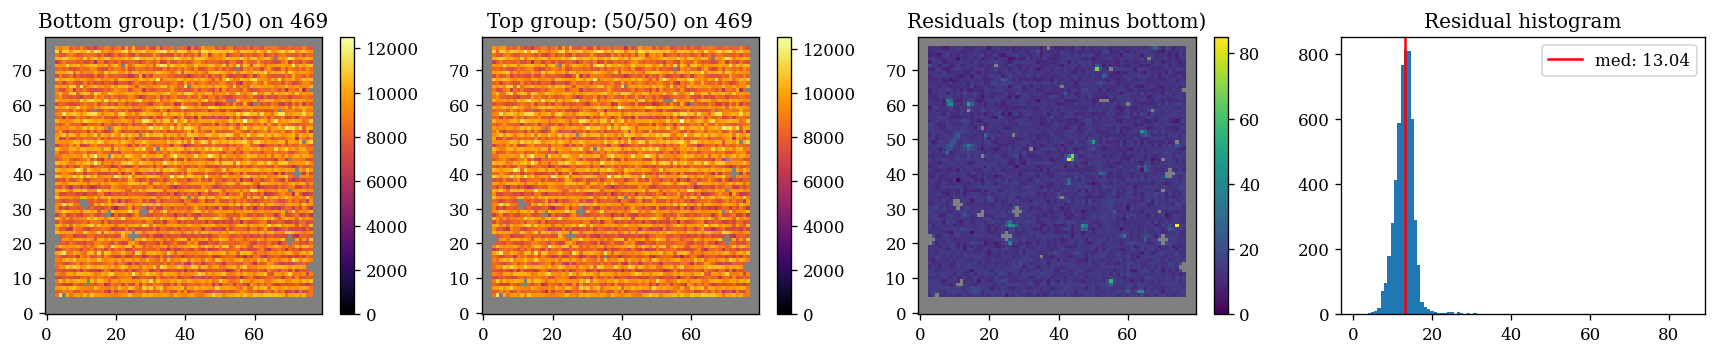

F430M


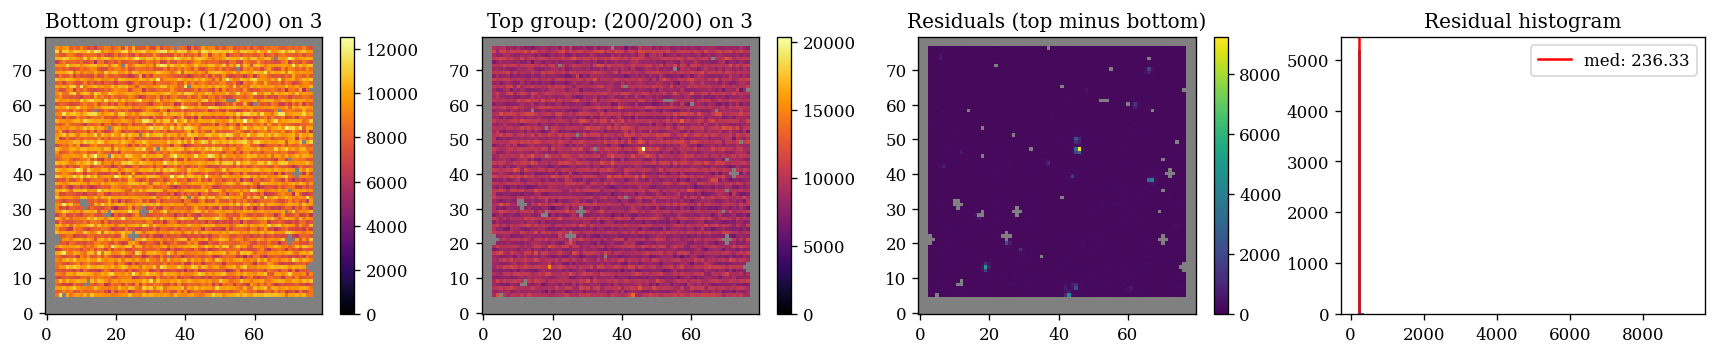

F430M


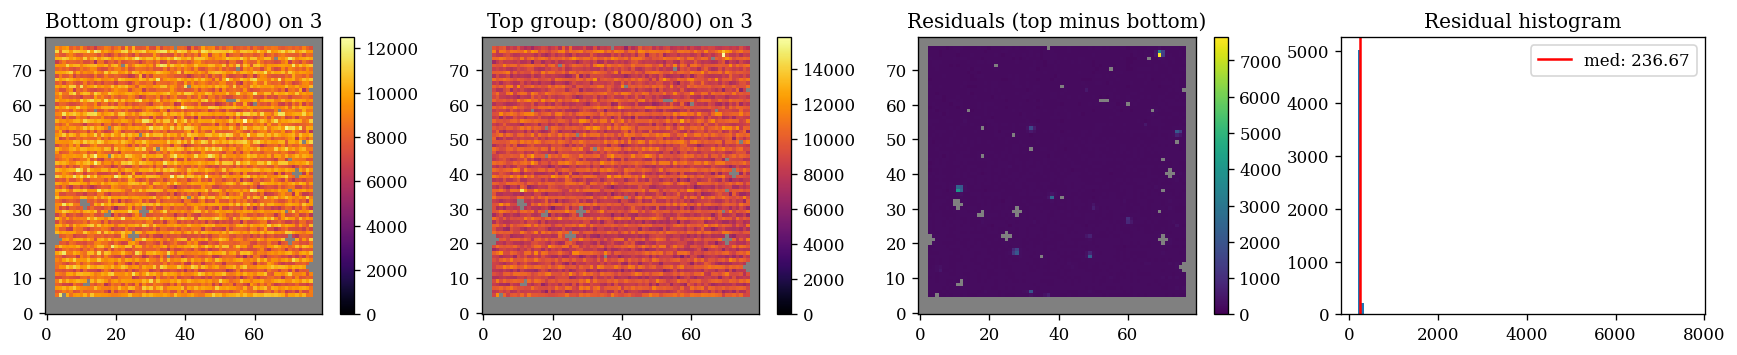

F430M


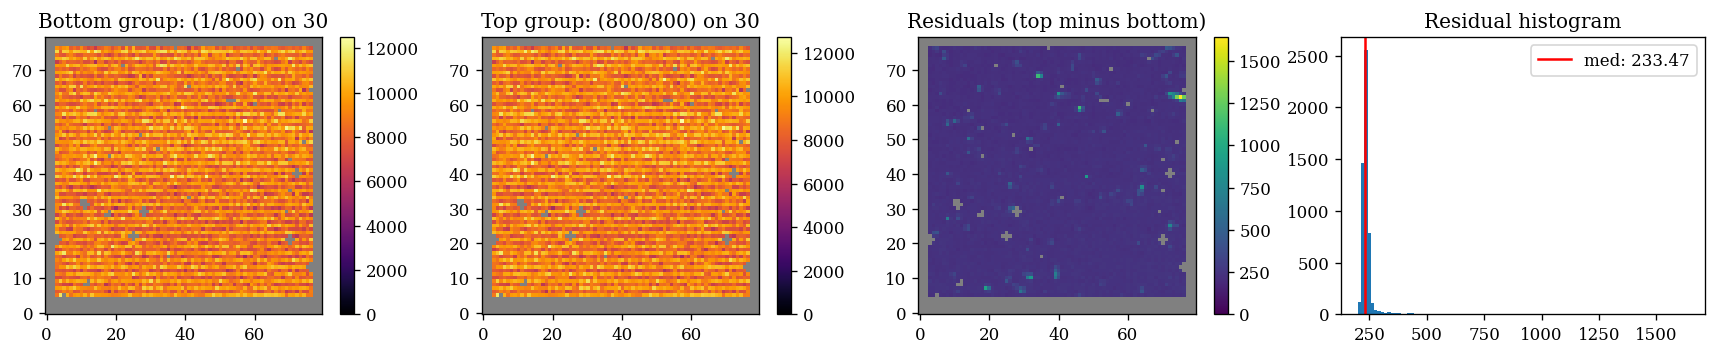

F430M


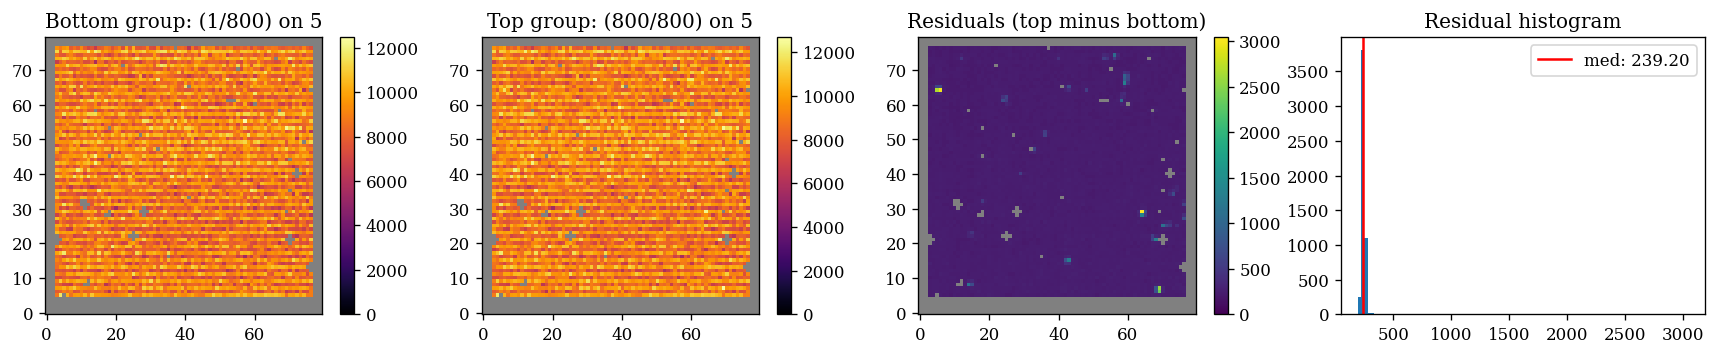

F430M


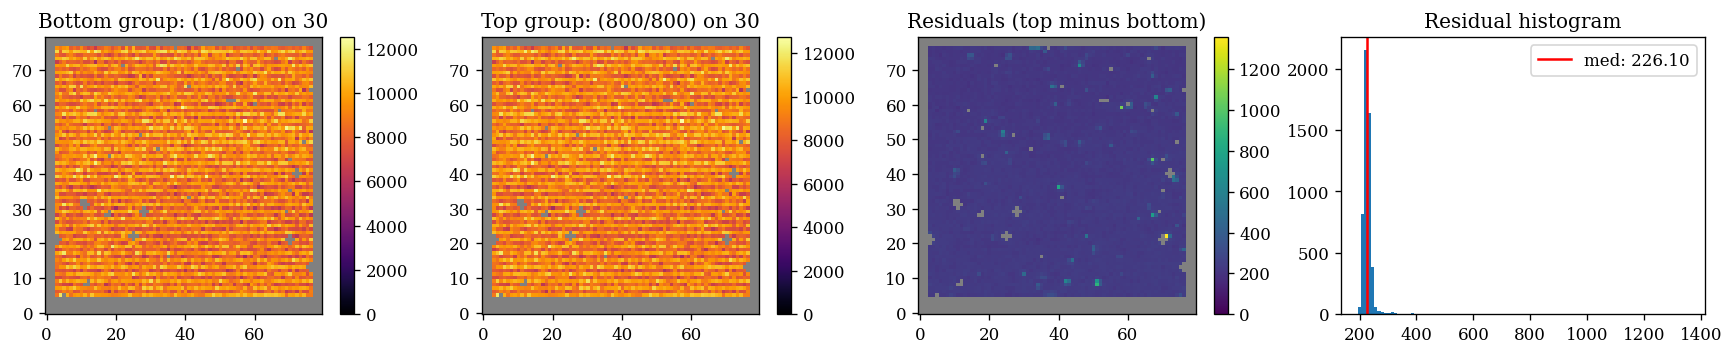

F430M


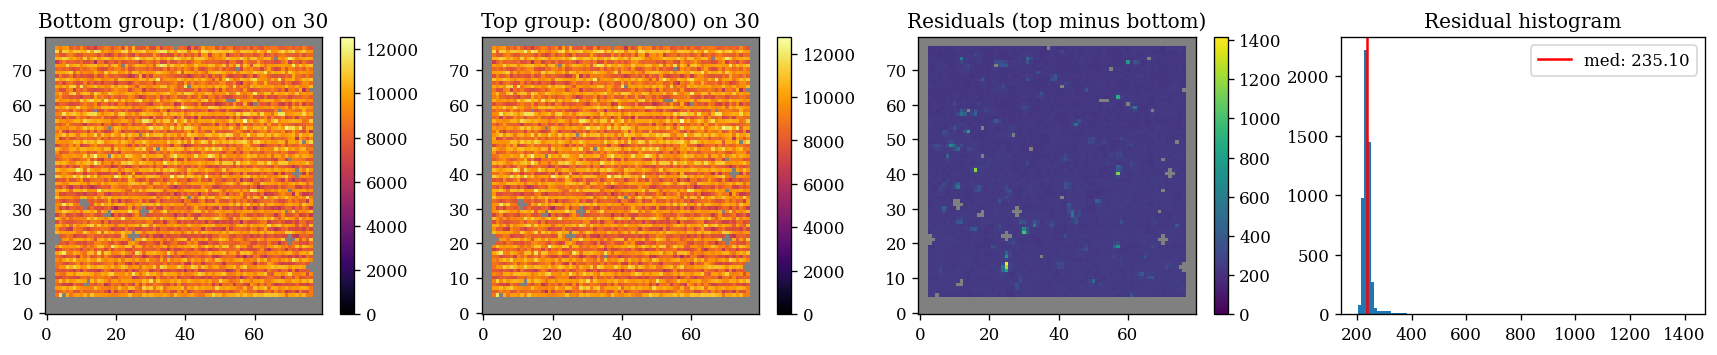

F430M


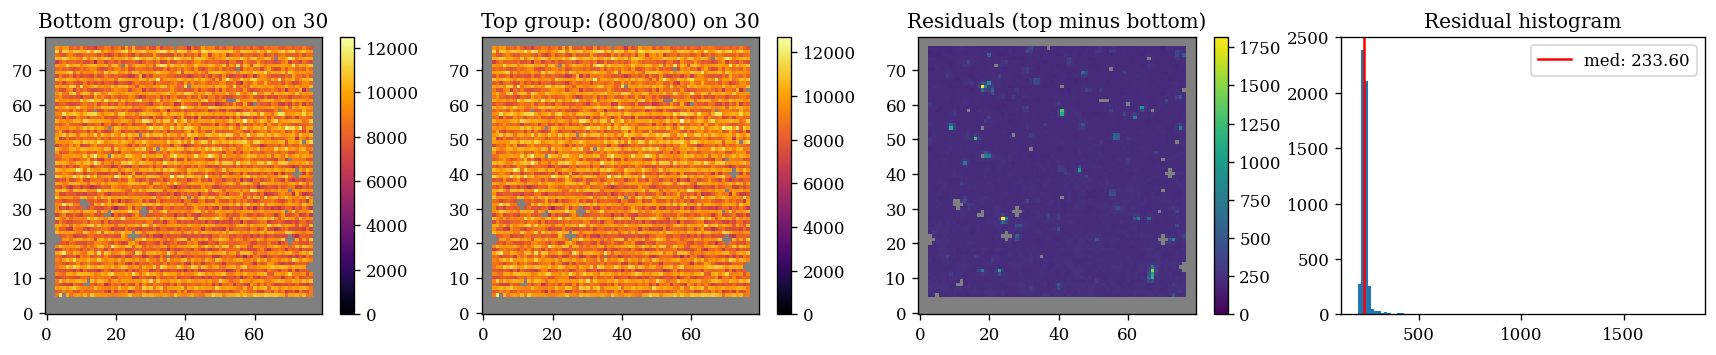

F430M


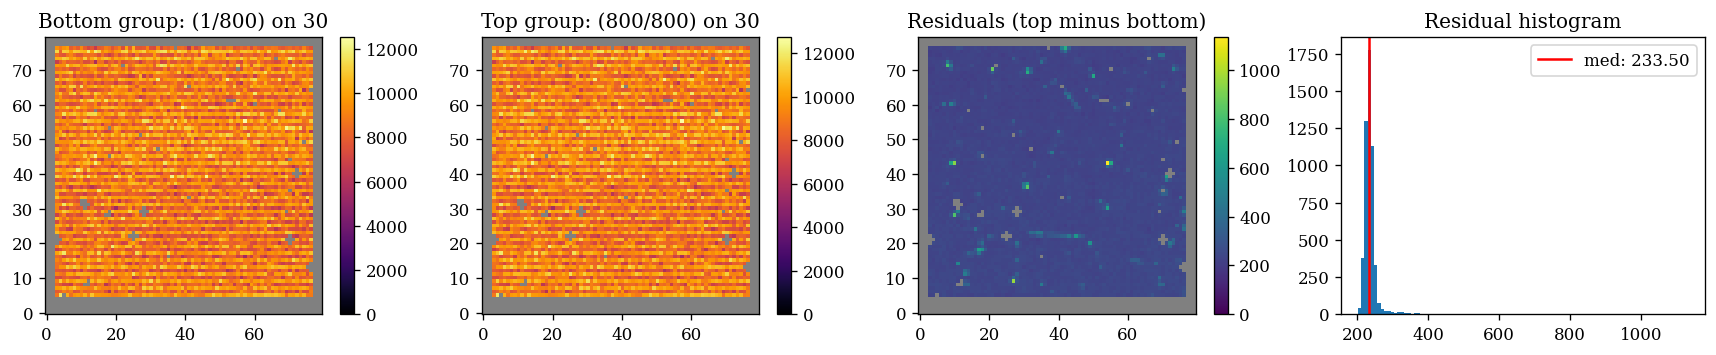

F430M


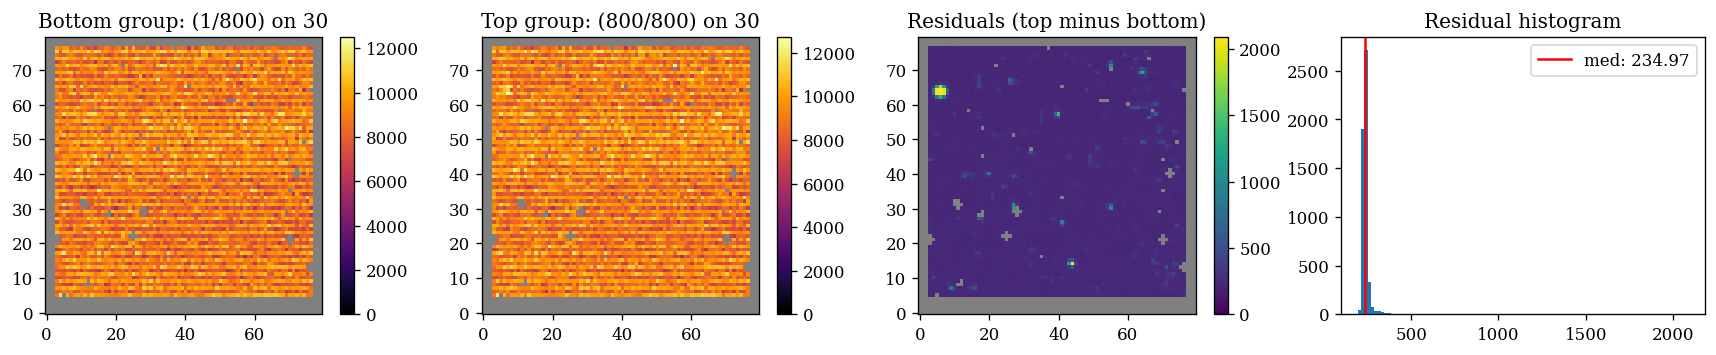

F430M


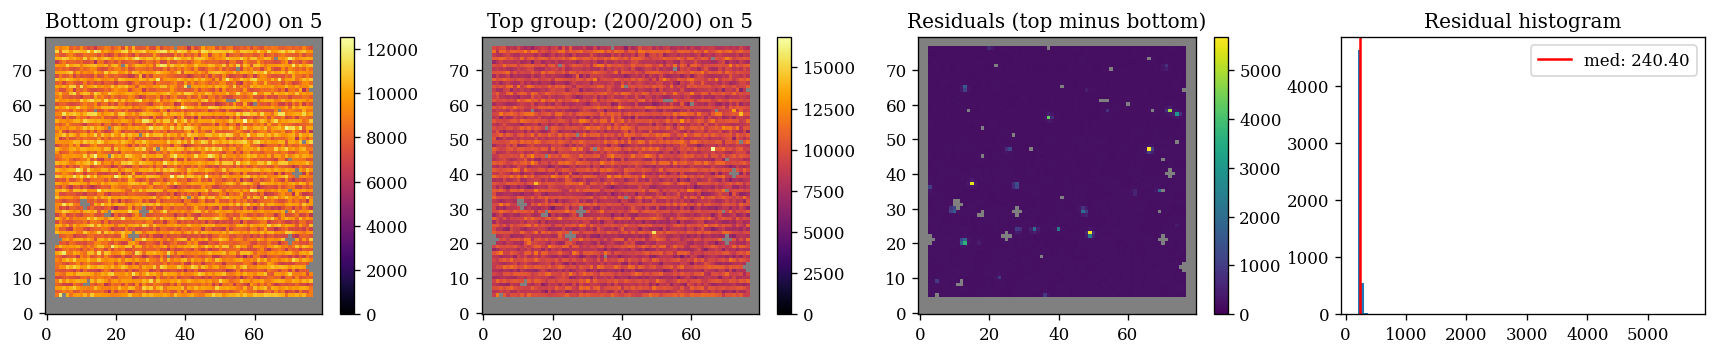

F430M


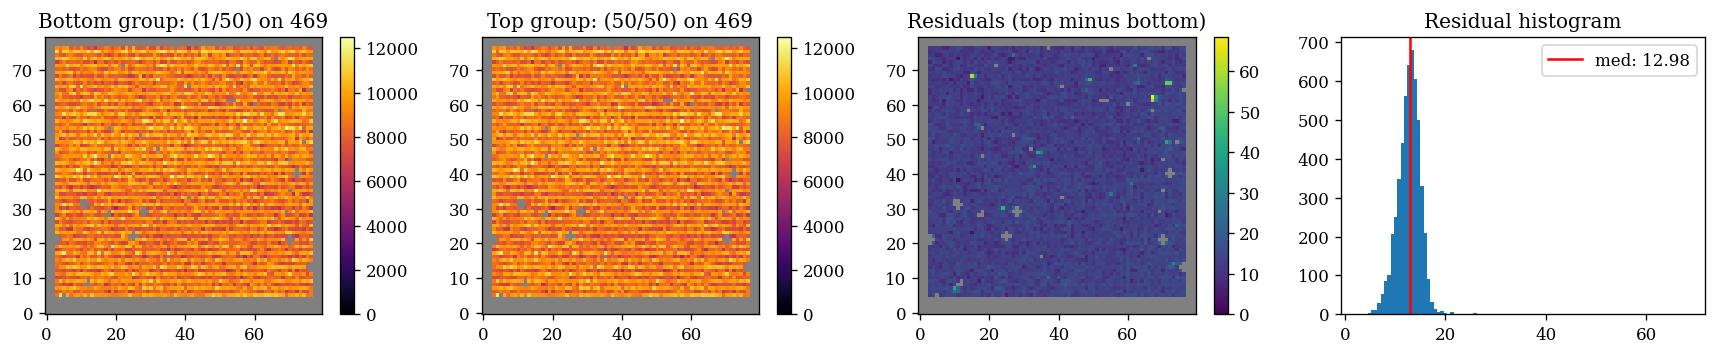

F430M


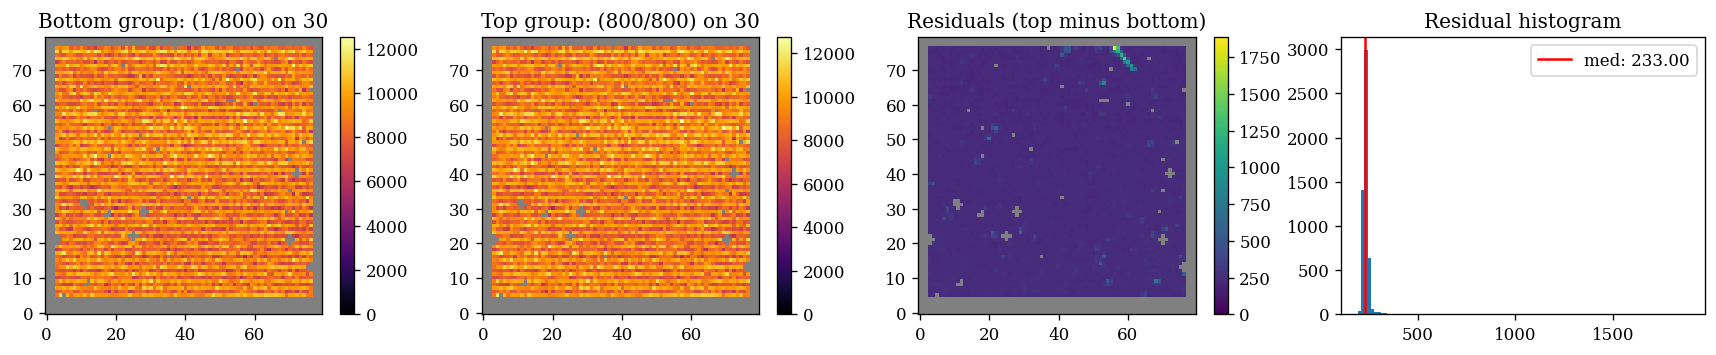

F430M


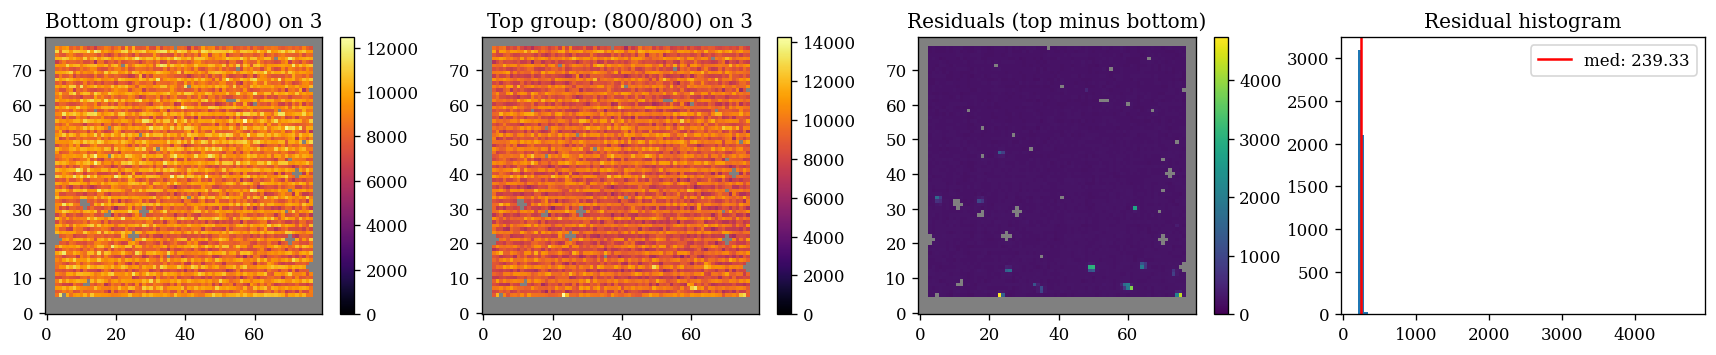

F430M


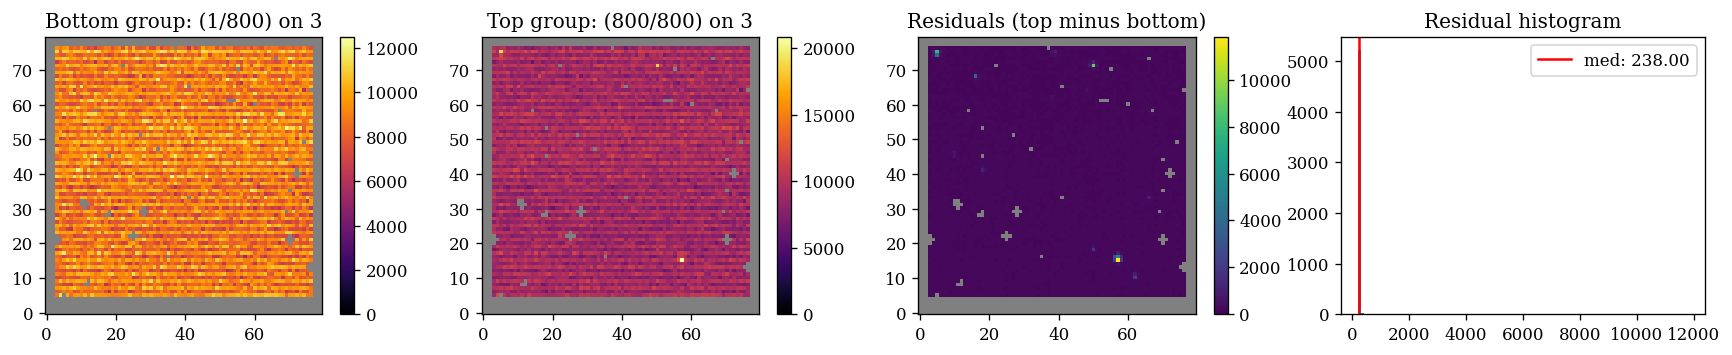

F430M


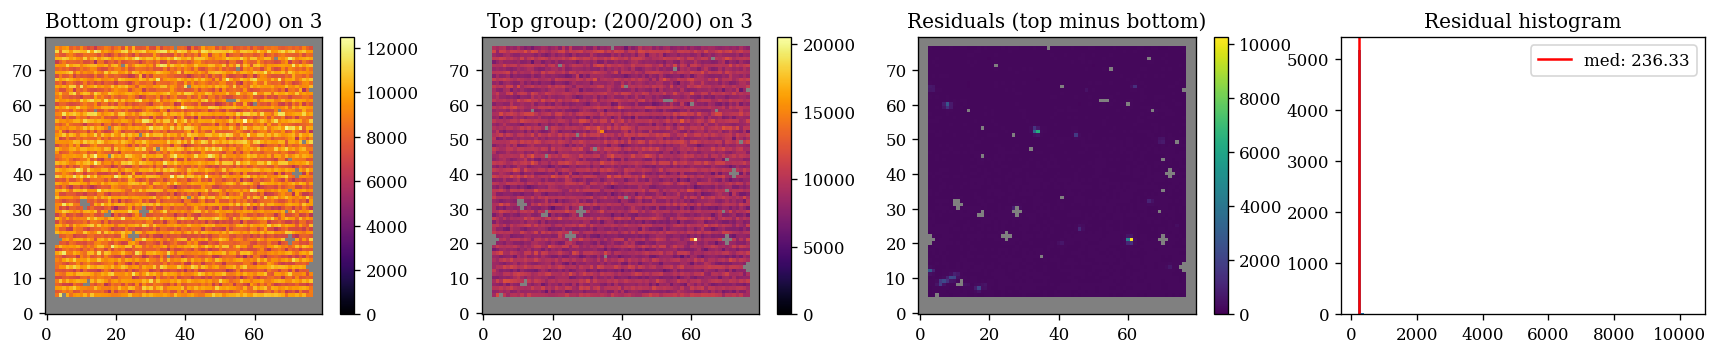

F430M


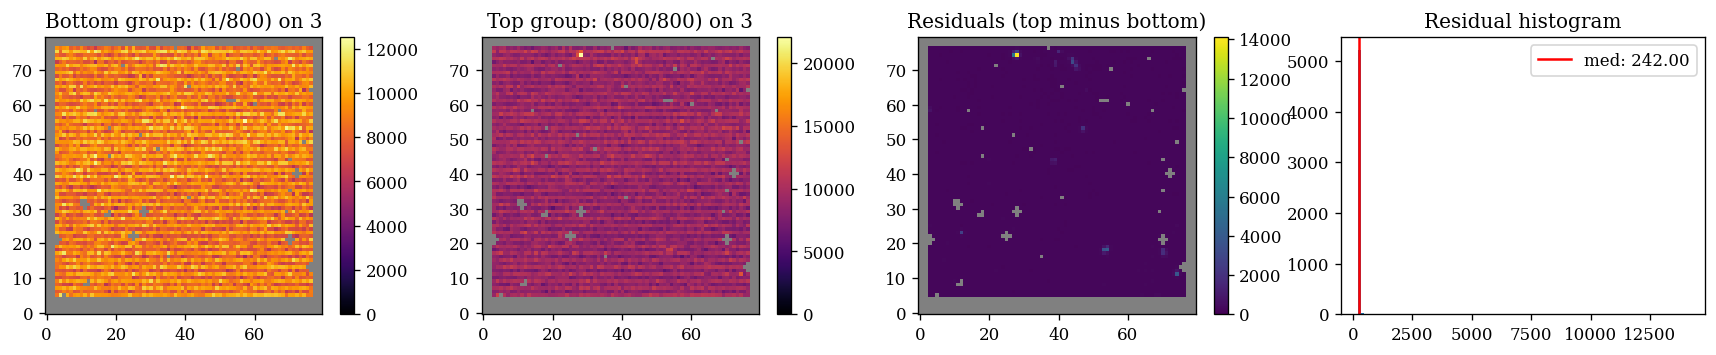

F430M


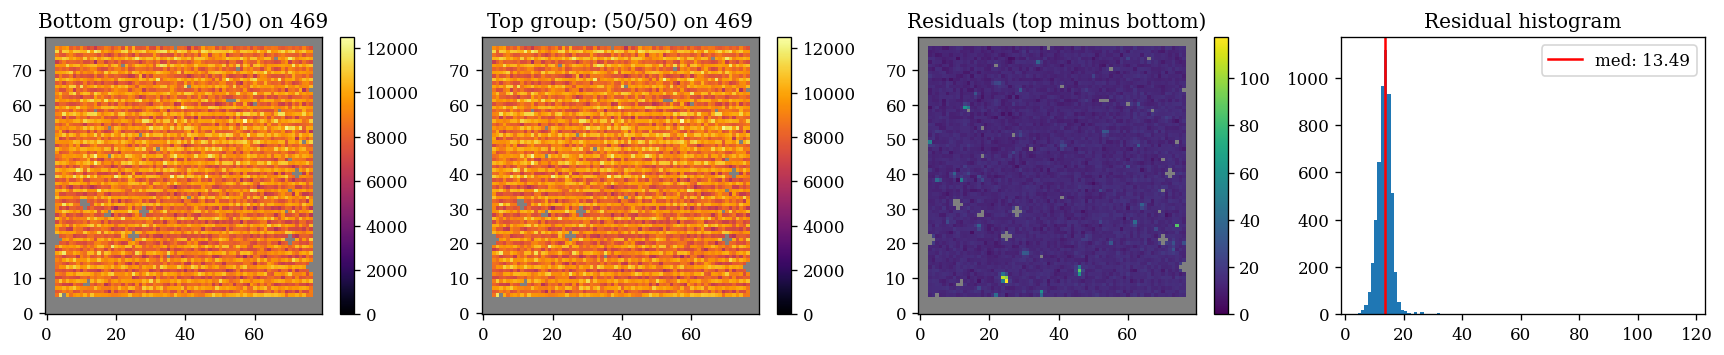

F430M


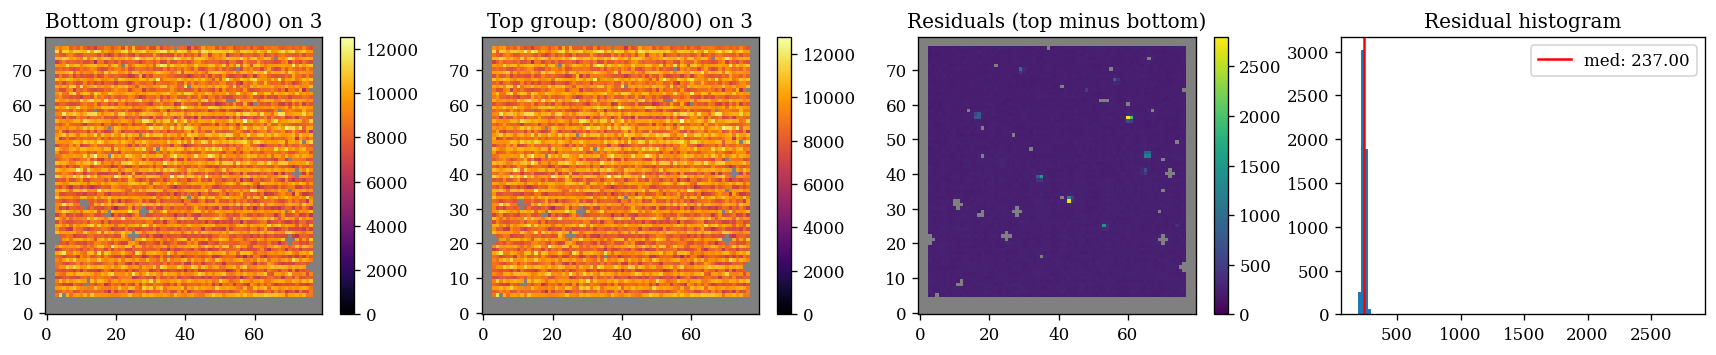

F430M


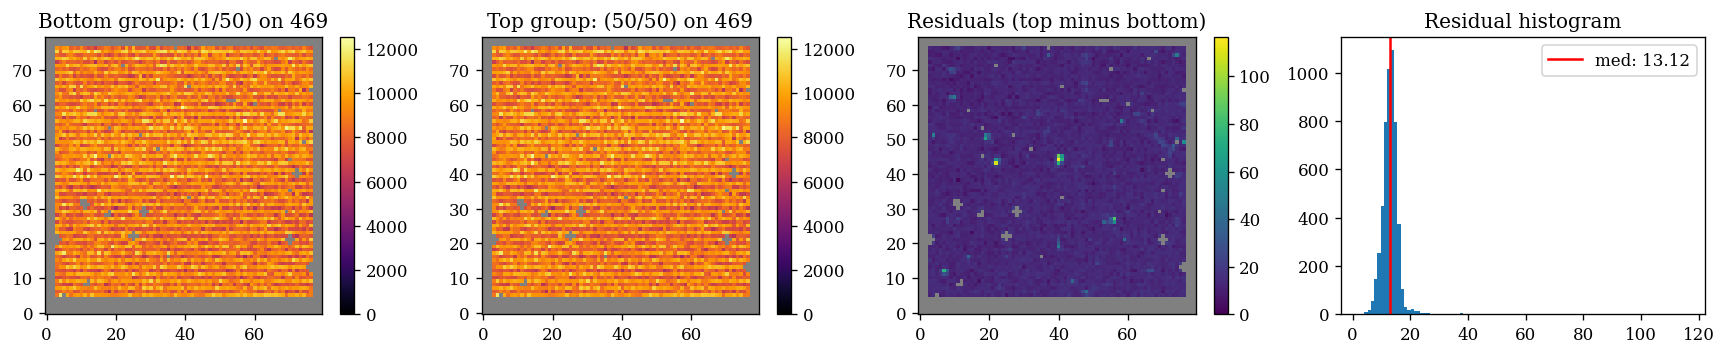

F430M


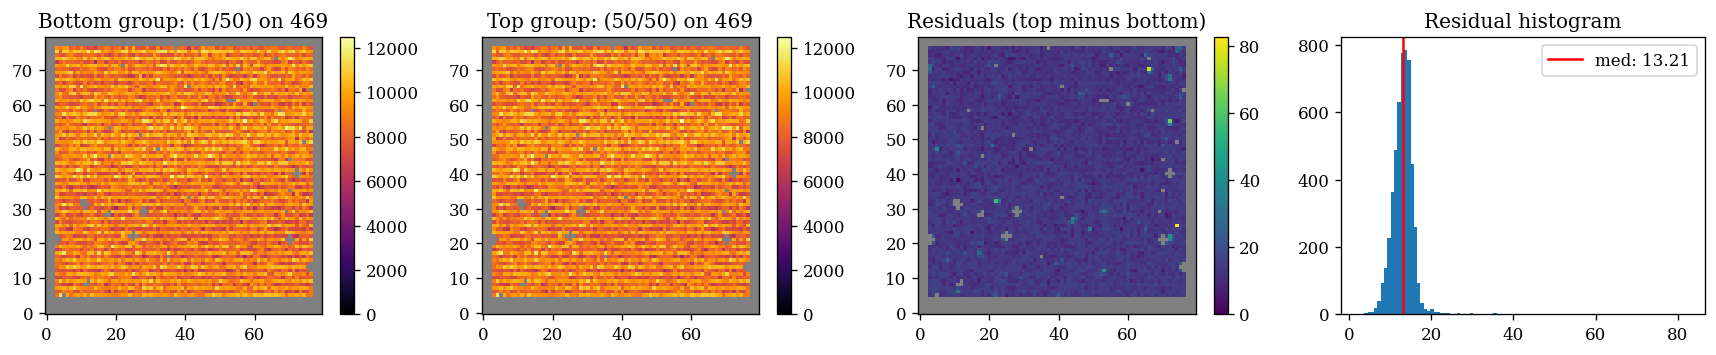

F430M


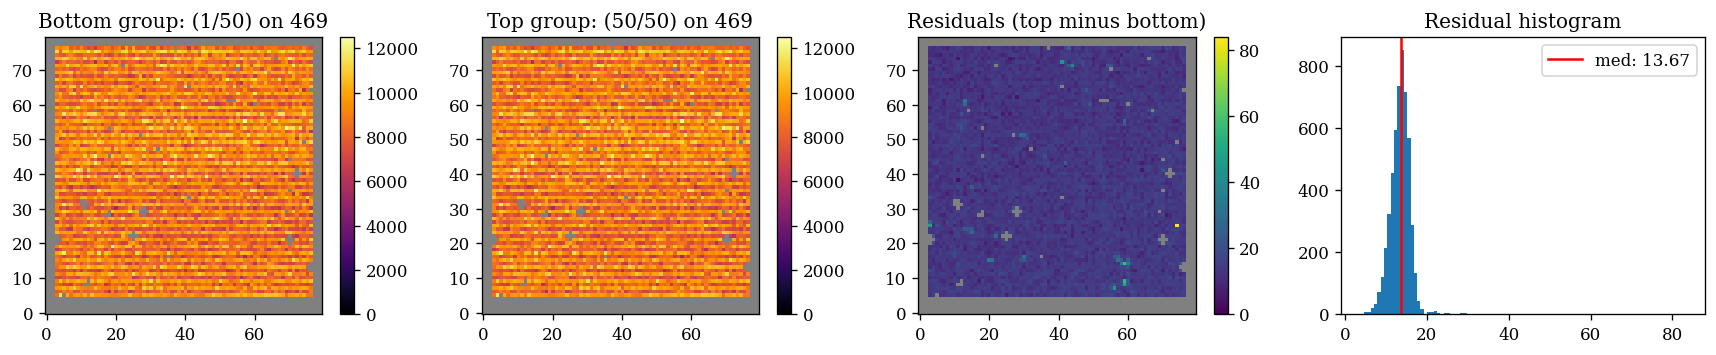

F430M


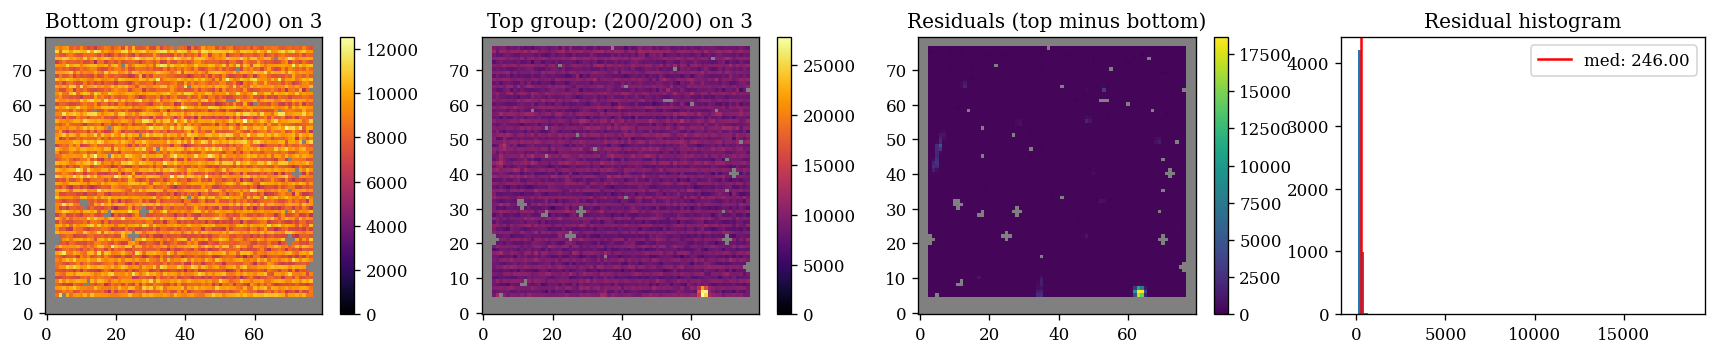

F430M


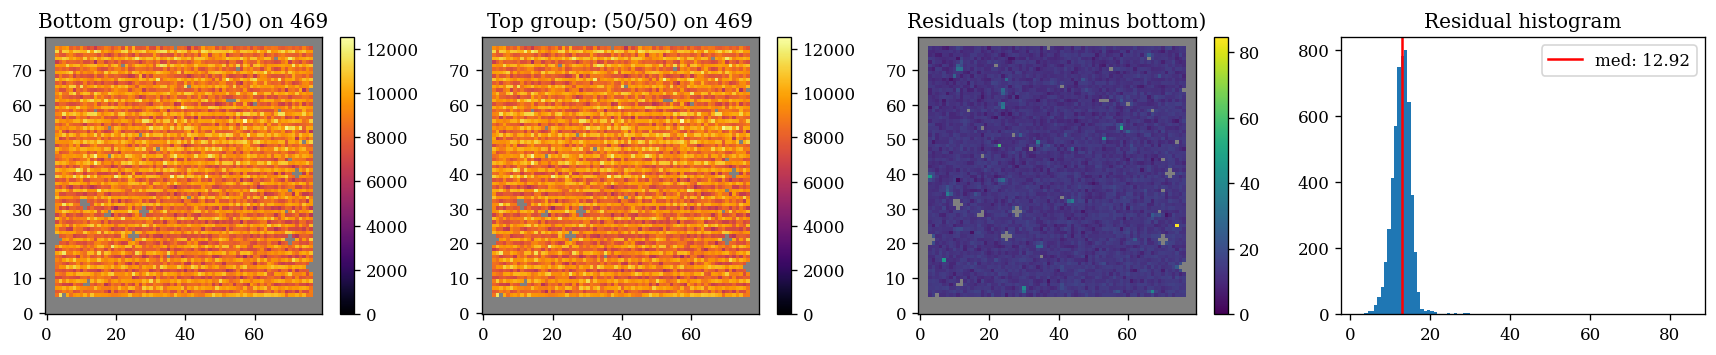

F430M


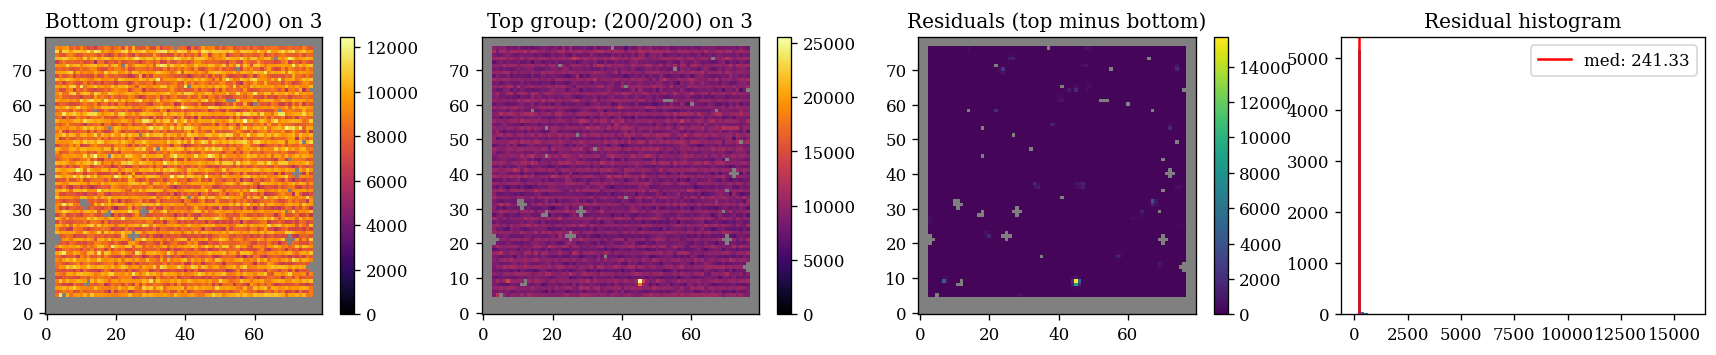

In [4]:
def summarise(file):
    hdu = file[0].header
    ramp = file[1].data
    print(hdu["FILTER"])

    fig, ax = plt.subplots(1, 4, figsize=(18, 3))

    bottom = np.array(ramp.mean(axis=0)[0])  # average bottom group
    top = np.array(file[1].data.mean(axis=0)[-1])  # average top group
    residuals = top - bottom

    bottom = bottom.at[badpix].set(np.nan)
    top = top.at[badpix].set(np.nan)
    residuals = residuals.at[badpix].set(np.nan)

    im = ax[0].imshow(bottom, inferno, norm=mpl.colors.PowerNorm(1., vmin=0))
    ax[0].set(title=f"Bottom group: (1/{hdu["NGROUPS"]}) on {hdu["NINTS"]}")
    fig.colorbar(im, ax=ax[0])

    im = ax[1].imshow(top, inferno, norm=mpl.colors.PowerNorm(1., vmin=0))
    ax[1].set(title=f"Top group: ({hdu["NGROUPS"]}/{hdu["NGROUPS"]}) on {hdu["NINTS"]}")
    fig.colorbar(im, ax=ax[1])

    im = ax[2].imshow(residuals, viridis, vmin=0, vmax=None)
    ax[2].set(title="Residuals (top minus bottom)")
    fig.colorbar(im, ax=ax[2])

    med = np.nanmedian(residuals)
    ax[3].hist(residuals.ravel(), bins=100)
    ax[3].axvline(med, color="red", label=f"med: {med:.2f}")
    ax[3].legend()
    ax[3].set(title="Residual histogram")

    plt.show()


for f in files:
    summarise(f)

## Making Masters

In [5]:
from tqdm.auto import tqdm

masters = {}

for f in tqdm(files):
    hdu = f[0].header
    n_ints = hdu["NINTS"]
    n_groups = hdu["NGROUPS"]

    if n_ints < 30:
        print(f"Skipping, low integrations ({n_ints})")
        continue

    idstr = f"{n_groups}_groups"
    if idstr not in masters:
        masters[idstr] = []
    masters[idstr].append(f[1].data)

for key, data in masters.items():
    data = np.concatenate(data, axis=0)
    masters[key] = data
    print(f"{key}: {data.shape}")

for f in files:
    f.close()

  0%|          | 0/28 [00:00<?, ?it/s]

Skipping, low integrations (3)
Skipping, low integrations (3)
Skipping, low integrations (5)
Skipping, low integrations (5)
Skipping, low integrations (3)
Skipping, low integrations (3)
Skipping, low integrations (3)
Skipping, low integrations (3)
Skipping, low integrations (3)
Skipping, low integrations (3)
Skipping, low integrations (3)
50_groups: (3752, 50, 80, 80)
800_groups: (270, 800, 80, 80)


In [10]:
def amend_header(file):
    hdu = file[0].header
    hdu["DATE"] = None
    hdu["FILENAME"] = None
    hdu["HGA_MOVE"] = None
    hdu["HGA_STRT"] = None
    hdu["HGA_STOP"] = None
    hdu["PWFSEET"] = None
    hdu["NWFSEST"] = None

    hdu["DATE-OBS"] = None
    hdu["TIME-OBS"] = None
    hdu["DATE-BEG"] = None
    hdu["DATE-END"] = None
    hdu["OBS_ID"] = None
    hdu["EXPOSURE"] = None

    hdu["VSTSTART"] = None

    hdu["VA_RA"] = None
    hdu["VA_DEC"] = None

    hdu["BARTDELT"] = None
    hdu["BSTRTIME"] = None
    hdu["BENDTIME"] = None
    hdu["BMIDTIME"] = None
    hdu["HELIDELT"] = None
    hdu["HSTRTIME"] = None
    hdu["HENDTIME"] = None
    hdu["HMIDTIME"] = None

    file[0].header = hdu
    return file

In [16]:
import shutil

I469 = False
I30 = False

out_dir = "/Volumes/research-data/PRJ-PAT/max/data/JWST/DARKS/uncal"


def stack_new_fits(file, nints=n_ints, ngroups=n_groups):
    file = amend_header(file)
    new_hdu = file[0].header
    file.close()

    new_name = f"masterdark_{nints}_uncal.fits"
    out_file = os.path.join(out_dir, new_name)
    shutil.copy(os.path.join(uncal_dir, f), out_file)

    file = fits.open(out_file)
    file[0].header = new_hdu
    file[0].header["FILENAME"] = new_name
    file[1].data = masters[f"{ngroups}_groups"]
    file.writeto(out_file, overwrite=True)
    file.close()


for f in os.listdir(uncal_dir):
    if f.startswith("."):
        continue
    file = fits.open(os.path.join(uncal_dir, f))
    hdu = file[0].header
    nints = hdu["NINTS"]
    ngroups = hdu["NGROUPS"]
    if nints == 469 and not I469:
        print(f"Found 469 ints: {f}")
        I469 = True
        stack_new_fits(file, nints=nints, ngroups=ngroups)

    if nints == 30 and not I30:
        print(f"Found 30 ints: {f}")
        I30 = True
        stack_new_fits(file, nints=nints, ngroups=ngroups)
    file.close()

Found 469 ints: jw06652008001_08201_00001_nis_uncal.fits
Found 30 ints: jw01499023001_05201_00001_nis_uncal.fits
